# HH2 - Step 4: Predictions (tests)

## Algorithm curent plan:
- Predict indoor temperatures from outdoor temperatures (forecasts), sunlight (forecasts), and window states (loop over all possibilities?)
> the max and min possible indoor temperatures for any presets

- update DF dataset with max and min possible indoor temperatures (range)
> user via interface: sets their desired range --> update another DF dataset with matching window state presets
>> based on correlations for each preset --> if corr > threshold corr: add to action list on interface (e.g.: "open window + temperature effect (e.g. +1°C")

- heating/thermostat:
> add slider to set thermostat setting? == (artificial) lower indoor temp limit

### Import libraries 

In [13]:
#Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn' ## disable chained assignment warnings due to false positives
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
#Plotly is a Python data visualization library 
import plotly.graph_objects as go
import plotly.express as px
import datetime as dt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Import metrics
from sklearn.ensemble import RandomForestRegressor

### Load and view data 

In [112]:
# Get the merged database (saved at the end of notebook STEP 1)
database = pd.read_csv (r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\2_visualized.csv")
database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\2_hourly.csv")
database_H1 = pd.read_csv (r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H1\DATA (backups)\2_visualized.csv")


database_hourly.drop(['weather_main', 'outdoor-API', 'Temperature_mean_outdoor'], axis=1, inplace=True)
database.drop(['weather_main', 'outdoor-API', 'Temperature_mean_outdoor', "Temperature_outdoor"], axis=1, inplace=True)
database_H1.drop(['weather_main'], axis=1, inplace=True)

display(database_hourly.head(10))

,date,hr,ts,Temperature_indoor,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,weather_description,window_door,distance_right,light_right,curtain_right,shade_right,distance_left,light_left,curtain_left,shade_left,Temperature_outdoor
0,2024-08-28,18,2024-08-28 18:00:00,28.1,29.4,31.0,28.2,scattered clouds,1.0,60.0,1808.0,1.0,1.0,15.0,2769.0,0.0,0.0,30.0000
1,2024-08-28,19,2024-08-28 19:00:00,27.9,28.9,30.0,27.6,scattered clouds,1.0,341.0,1685.0,1.0,1.0,799.0,2485.0,1.0,0.0,30.0000
2,2024-08-28,20,2024-08-28 20:00:00,27.6,26.8,28.9,25.6,clear sky,0.0,219.0,1424.0,1.0,1.0,339.0,2106.0,1.0,0.0,27.8125
3,2024-08-28,21,2024-08-28 21:00:00,27.2,24.4,25.6,23.0,clear sky,1.0,308.0,0.0,1.0,1.0,463.0,0.0,1.0,1.0,26.1250
4,2024-08-28,22,2024-08-28 22:00:00,27.1,22.0,24.0,20.6,scattered clouds,0.0,16.0,0.0,0.0,1.0,11.0,0.0,0.0,1.0,25.0625
5,2024-08-28,23,2024-08-28 23:00:00,27.0,21.3,22.7,19.9,broken clouds,0.0,16.0,0.0,0.0,1.0,11.0,0.0,0.0,1.0,24.1875
6,2024-08-29,0,2024-08-29 00:00:00,26.8,20.6,22.2,19.0,broken clouds,0.0,16.0,0.0,0.0,1.0,11.0,0.0,0.0,1.0,24.1875
7,2024-08-29,1,2024-08-29 01:00:00,26.8,20.7,22.1,18.8,scattered clouds,0.0,14.0,0.0,0.0,1.0,11.0,0.0,0.0,1.0,23.5625
8,2024-08-29,2,2024-08-29 02:00:00,26.7,20.1,21.6,18.2,scattered clouds,0.0,14.0,0.0,0.0,1.0,11.0,0.0,0.0,1.0,23.0000
9,2024-08-29,3,2024-08-29 03:00:00,26.6,19.8,20.5,17.7,few clouds,0.0,14.0,0.0,0.0,1.0,11.0,0.0,0.0,1.0,22.0625


## Baseline model (mean prediction)

In [80]:
## BASELINE MODEL (mean prediction)
# Load your data
df = database

# Data preparation
df['date'] = pd.to_datetime(df['date'])
df = pd.get_dummies(df, columns=['weather_description'], drop_first=True)

# Remove rows with NaN values
df.dropna(inplace=True)  # This line removes any rows that contain NaN values

# Define features and target
X = df.drop(columns=['Temperature_indoor', 'date', 'ts'])
y = df['Temperature_indoor']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


# Assuming y_train is your training target variable and y_test is your test target variable

# Step 1: Calculate the mean of the training target variable
mean_prediction = np.mean(y_train)

# Step 2: Create predictions for the test set using the mean
y_pred_baseline = np.full_like(y_test, mean_prediction)

# Step 3: Evaluate the baseline model using MAE
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)

print(f'Baseline MAE (Mean Prediction): {baseline_mae}')

Baseline MAE (Mean Prediction): 1.497511760102043


# Random forest model

In [98]:
# Load your data
df = database

# Data preparation
df['date'] = pd.to_datetime(df['date'])
df = pd.get_dummies(df, columns=['weather_description'], drop_first=True)

# Remove rows with NaN values
df.dropna(inplace=True)  # This line removes any rows that contain NaN values

# Define features and target
X = df.drop(columns=['Temperature_indoor', 'date', 'ts'])
y = df['Temperature_indoor']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Train the model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)  # Calculate R-squared value

# Print the evaluation metrics
print(f'MAE: {mae}, MSE: {mse}, R-squared: {r2}')  # Print the evaluation metrics including R-squared

MAE: 0.25055683204316115, MSE: 0.19572736867327972, R-squared: 0.9417804019896008


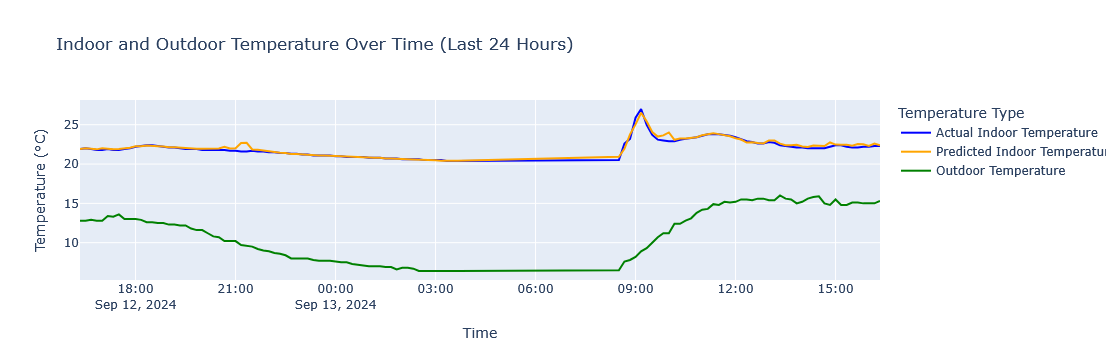

In [100]:
# Convert 'ts' column to datetime format if it's not already
df['ts'] = pd.to_datetime(df['ts'])  # Convert 'ts' to datetime

# Create a new DataFrame to hold the actual and predicted values along with outdoor temperature
results_df = df[['ts', 'Temperature_indoor']].copy()  # Copy the time series and actual indoor temperature
results_df['Predicted_Temperature'] = model.predict(X)  # Add predicted indoor temperature using the model
results_df['Temperature_API'] = df['Temperature_API']  # Include outdoor temperature from the original dataframe

# Filter the results to include only the last 24 hours
last_24_hours = results_df[results_df['ts'] >= results_df['ts'].max() - pd.Timedelta(hours=24)]  # Select data from the last 24 hours

with warnings.catch_warnings(): ## Ignore this future warning since it is a Plotly problem, not a problem with my code
    warnings.simplefilter("ignore", FutureWarning)
    # Create the plotly figure
    fig = go.Figure()
    
    # Add traces for actual indoor temperature, predicted indoor temperature, and outdoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['Temperature_indoor'], mode='lines', name='Actual Indoor Temperature', line=dict(color='blue')))  # Trace for actual indoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['Predicted_Temperature'], mode='lines', name='Predicted Indoor Temperature', line=dict(color='orange')))  # Trace for predicted indoor temperature
    fig.add_trace(go.Scatter(x=last_24_hours['ts'], y=last_24_hours['Temperature_API'], mode='lines', name='Outdoor Temperature', line=dict(color='green')))  # Trace for outdoor temperature
    
    # Update layout
    fig.update_layout(title='Indoor and Outdoor Temperature Over Time (Last 24 Hours)',  # Set the title of the plot
                      xaxis_title='Time',  # Label for the x-axis
                      yaxis_title='Temperature (°C)',  # Label for the y-axis
                      legend_title='Temperature Type',  # Title for the legend
                      hovermode='x')  # Enable hover mode for better interaction
    
    # Show the plot
    fig.show()  # Display the plot

In [42]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
   'n_estimators': [100, 200, 300],
   'max_depth': [None, 10, 20, 30],
   'min_samples_split': [2, 5, 10],
   'min_samples_leaf': [1, 2, 4],
   'max_features': [1.0, 'sqrt', 'log2']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')

# Retrieve the best estimator from the grid search
best_model = grid_search.best_estimator_

# Now you can use best_model to make predictions on your test data
y_pred = best_model.predict(X_test)

# Optionally, you can evaluate the model's performance
from sklearn.metrics import mean_absolute_error

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)  # Calculate R-squared value

print(f'MAE: {mae}, MSE: {mse}, R-squared: {r2}')  # Print the evaluation metrics including R-squared

Best parameters: {'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
MAE: 0.17485160367227628, MSE: 0.10559523882386405, R-squared: 0.968137955324088


In [44]:
# **Cross-Validation**: Instead of a single train-test split, use k-fold cross-validation to assess the model's performance more robustly. 
# This helps in understanding how the model generalizes to an independent dataset.
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')   # Use negative MAE for scoring
# Calculate the mean of the cross-validated scores and negate it to get the actual MAE
print(f'Cross-validated MAE: {-cv_scores.mean()}')  # Print the mean absolute error from cross-validation

Cross-validated MAE: 1.1332587446037665


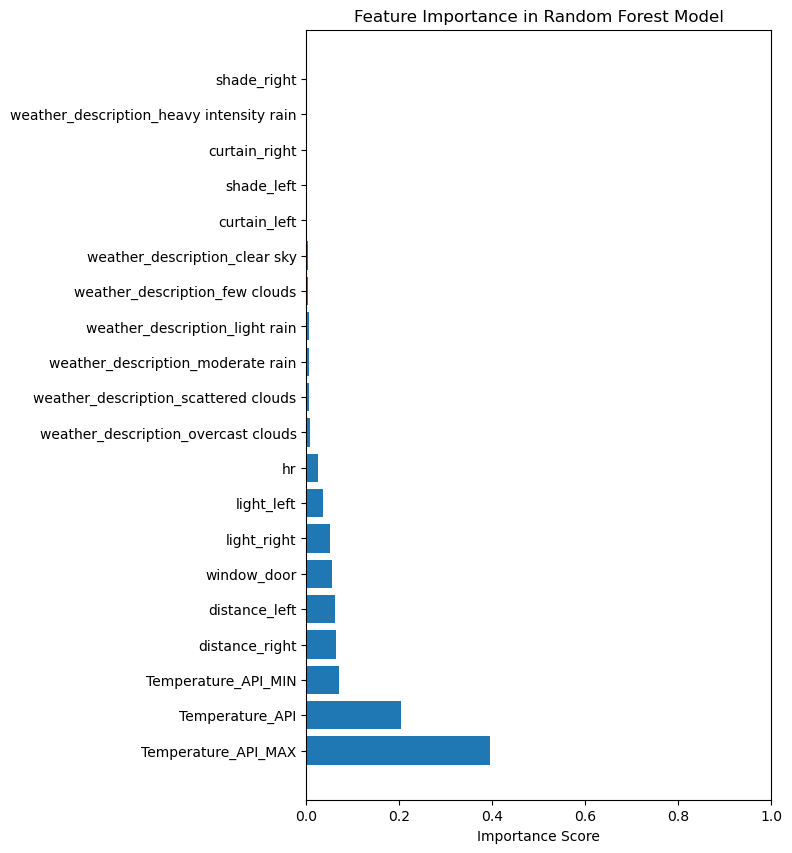

In [110]:
#**Feature Importance**: Analyze the importance of each feature in the model to understand which variables are contributing the most to the predictions.
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the model
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances (flipped)
plt.figure(figsize=(6, 10))  # Adjust height for better visualization
plt.title("Feature Importance in Random Forest Model")
plt.barh(X.columns[indices], importances[indices], align="center")  # Use barh for horizontal bars
plt.xlabel("Importance Score")
plt.xlim([0, 1])  # Set x-axis limits to 0 and 1 for normalized importance scores
plt.show()


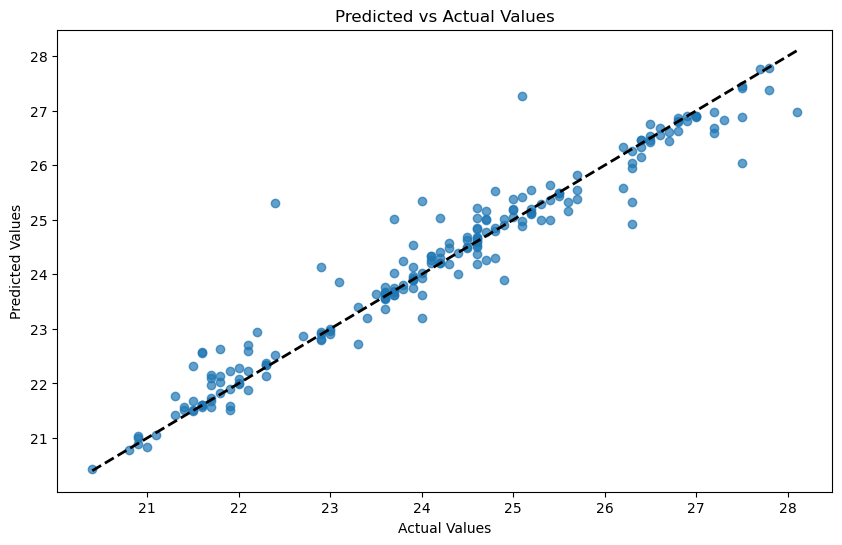

In [66]:
### 2. Predicted vs Actual Values

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values")
plt.show()

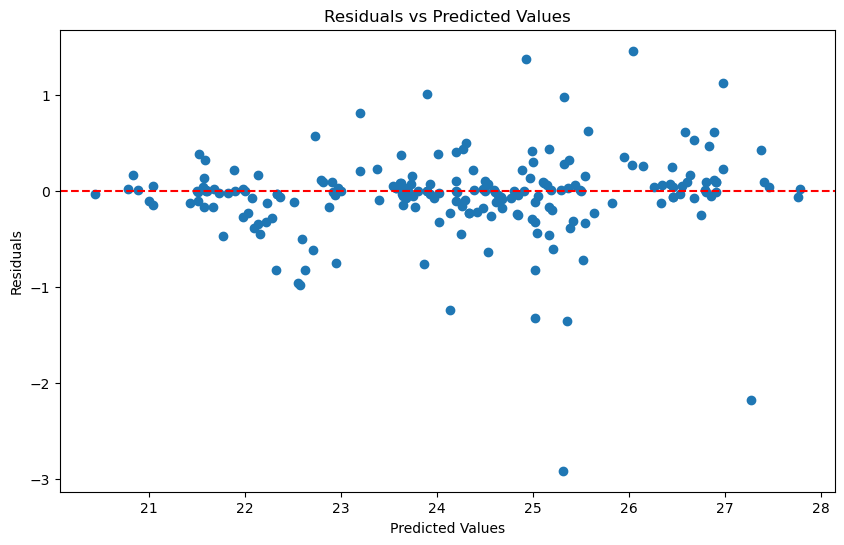

In [68]:
# **Residual Analysis**: Examine the residuals (the differences between predicted and actual values) to check for patterns. Ideally, residuals should be randomly distributed.
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()   

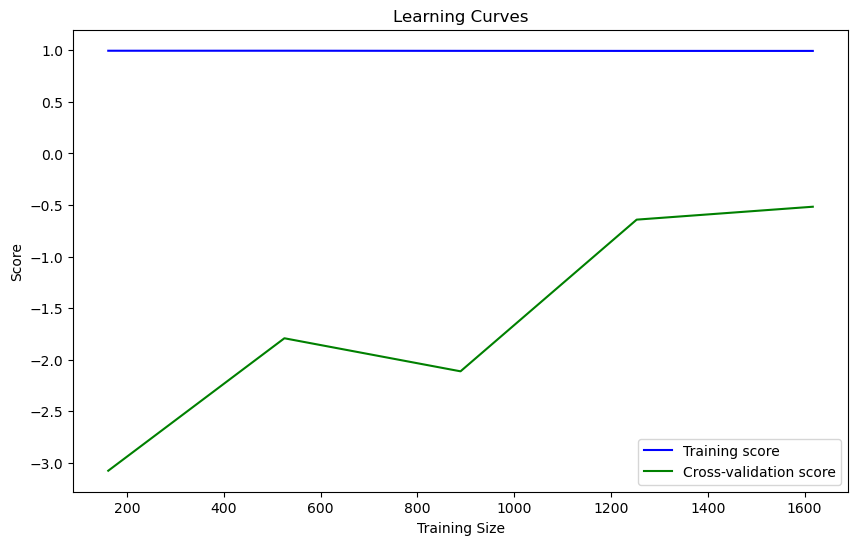

In [70]:
# **Learning Curves**: Plot learning curves to visualize how the model's performance changes with varying training set sizes. 
# This can help identify if the model is underfitting or overfitting.
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=5, n_jobs=-1)

# Calculate mean and std for training and test scores
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training score', color='blue')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation score', color='green')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Learning Curves')
plt.legend()
plt.show()

# Linear Regression model

### OLD VERSION: 1.1 Percentual change per hour/minute for outdoor- and indoor temperature (database)

In [188]:
# OUTDOOR FACTOR
# database['factor_outdoor'] = database.Temperature_mean_outdoor.pct_change() # for the full database (per minute)
database_hourly_corr['factor_outdoor'] = database_hourly_corr.Temperature_API.pct_change(fill_method=None).round(2) # for the hourly databse (comparable to api forecast)
# database_hourly_corr.tail()

# INDOOR FACTOR
# database['factor_indoor'] = database.Temperature_indoor.pct_change() # for the full database (per minute)
database_hourly_corr['factor_indoor'] = database_hourly_corr.Temperature_indoor.pct_change(fill_method=None).round(2) # for the hourly databse (comparable to api forecast)
database_hourly_corr["indoor-API"] = (database_hourly_corr["Temperature_indoor"] - database_hourly_corr["Temperature_API"]).round(0)

database_hourly_corr.tail()

,ts,Temperature_indoor_corr,temperature_API_corr,window_door_corr,curtain_right_corr,shade_right_corr,curtain_left_corr,shade_left_corr,date,hr,...,curtain_left,shade_left,Temperature_outdoor,outdoor-API,Temperature_mean_outdoor,factor_outdoor,factor_indoor,indoor-API,Temperature_Comparison,Temperature_Comparison_Int
467,2024-09-17 05:00:00,1.0,-0.961524,NaN,NaN,NaN,NaN,NaN,2024-09-17,5.0,...,NaN,NaN,12.9375,0.0,12.71875,0.01,-0.00,9.0,Higher,1
468,2024-09-17 06:00:00,1.0,-0.674200,NaN,-0.632456,NaN,NaN,NaN,2024-09-17,6.0,...,NaN,NaN,13.6250,0.0,13.36250,0.05,-0.00,9.0,Higher,1
469,2024-09-17 07:00:00,1.0,-0.820665,NaN,NaN,NaN,NaN,NaN,2024-09-17,7.0,...,NaN,NaN,14.0000,1.0,13.70000,0.02,0.01,9.0,Higher,1
470,2024-09-17 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-17,8.0,...,NaN,NaN,14.5625,1.0,14.13125,0.02,-0.02,8.0,Higher,1
471,2024-09-17 09:00:00,1.0,0.966827,NaN,NaN,NaN,NaN,NaN,2024-09-17,9.0,...,NaN,NaN,19.7500,5.0,17.07500,0.05,0.00,7.0,Higher,1


In [190]:
# Create a new column 'Temperature_Comparison_Int' in the database_hourly_corr DataFrame
# This column will indicate the comparison as integer values:
# 1 if 'Temperature_indoor' is higher than 'Temperature_API',
# -1 if 'Temperature_indoor' is lower than 'Temperature_API',
# and 0 if they are equal
database_hourly_corr['Temperature_Comparison_Int'] = database_hourly_corr.apply(
    lambda row: 1 if row['Temperature_indoor'] > row['Temperature_API'] 
    else (-1 if row['Temperature_indoor'] < row['Temperature_API'] else 0), 
    axis=1
)
database_hourly_corr.head()

,ts,Temperature_indoor_corr,temperature_API_corr,window_door_corr,curtain_right_corr,shade_right_corr,curtain_left_corr,shade_left_corr,date,hr,...,curtain_left,shade_left,Temperature_outdoor,outdoor-API,Temperature_mean_outdoor,factor_outdoor,factor_indoor,indoor-API,Temperature_Comparison,Temperature_Comparison_Int
0,2024-08-28 18:00:00,1.0,0.870864,NaN,NaN,NaN,-0.327327,NaN,2024-08-28,18.0,...,0.0,0.0,30.0000,1.0,29.70000,NaN,NaN,-1.0,Lower,-1
1,2024-08-28 19:00:00,1.0,0.753145,0.654654,NaN,NaN,NaN,NaN,2024-08-28,19.0,...,1.0,0.0,30.0000,1.0,29.45000,-0.02,-0.01,-1.0,Lower,-1
2,2024-08-28 20:00:00,1.0,0.938154,-0.731709,NaN,NaN,NaN,-0.731709,2024-08-28,20.0,...,1.0,0.0,27.8125,1.0,27.30625,-0.07,-0.01,1.0,Higher,1
3,2024-08-28 21:00:00,1.0,0.698546,0.774597,-4.584742e-15,NaN,0.774597,NaN,2024-08-28,21.0,...,1.0,1.0,26.1250,2.0,25.26250,-0.09,-0.01,3.0,Higher,1
4,2024-08-28 22:00:00,1.0,0.638442,NaN,NaN,NaN,NaN,NaN,2024-08-28,22.0,...,0.0,1.0,25.0625,3.0,23.53125,-0.10,-0.00,5.0,Higher,1


### 1.2 Test the factors

The plan now is to use these factors as predictors for temperature shifts in indoor temperature based on the forecast temperature shifts.
- First apply the factor for one case (e.g. window closed, curtain closed).
- Note where the indoor temperature shifts more in reality -> add an extra factor (to increase or decrease temperature) for when e.g. the window is open.

Let's first try this on a test- and training set of the historical (hourly) database.

In [194]:
database_hourly_test = database_hourly_corr[(database_hourly_corr.ts < '2024-09-13 00:00:00')]
database_hourly_test = database_hourly_corr.copy()

In [196]:
## Split into train and test dataset

# Set the size of the testing set to the last 24 rows
test_size = 24
 
# Get the total number of rows in the dataset
total_rows = database_hourly_test.shape[0]

# Calculate the number of rows to be used for the training set
train_size = total_rows - test_size  # Training set size is the total rows minus the test set size

# Split the dataset into training and testing sets
train = database_hourly_test[0:train_size]  # Training set contains all rows except the last 24
test = database_hourly_test[train_size:]     # Testing set contains the last 24 rows

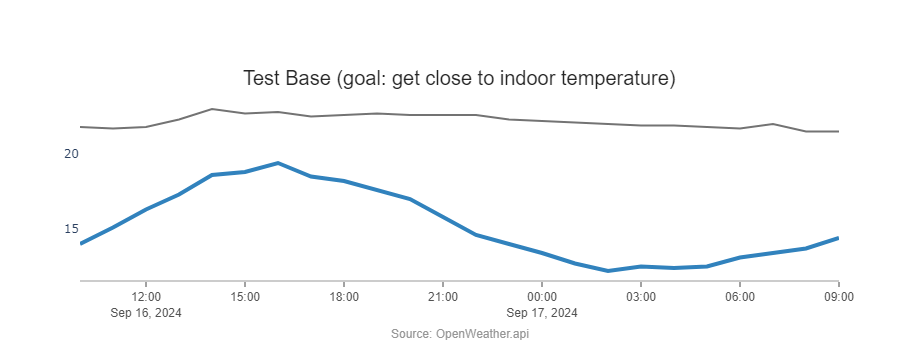

In [198]:
# Data to numpy array
x_data = test["ts"].values
y_data2 = test['Temperature_indoor'].values
y_data = test["Temperature_API"].values

# Define the figure with the data
fig = go.Figure()

fig.add_trace(go.Scatter(x=x_data, y=y_data, mode='lines',
    name='Forecast Temperature',
    line=dict(color= 'rgb(49,130,189)', width=4),
    connectgaps=True))

fig.add_trace(go.Scatter(x=x_data, y=y_data2, mode='lines',
        name='Indoor Temperature (real)',
        line=dict(color= 'rgb(115,115,115)', width=2),
        connectgaps=True))

# Define general layout
fig.update_layout(
    xaxis=dict(showline=True, showgrid=False, showticklabels=True, linecolor='rgb(204, 204, 204)', linewidth=2, ticks='outside', tickfont=dict(family='Arial', size=12, color='rgb(82, 82, 82)')),
    yaxis=dict(showgrid=False, zeroline=False, showline=False, showticklabels=True),
    autosize=True,
    showlegend=False,
    plot_bgcolor='white')

# Add and define title and other annotations
annotations = []
# Title
annotations.append(dict(xref='paper', yref='paper', x=0.5, y=1.05,xanchor='center', yanchor='bottom', text='Test Base (goal: get close to indoor temperature)', font=dict(family='Arial',size=20, color='rgb(37,37,37)'), showarrow=False))
# Source
annotations.append(dict(xref='paper', yref='paper', x=0.5, y=-0.25,xanchor='center', yanchor='top', text='Source: OpenWeather.api', font=dict(family='Arial',size=12,color='rgb(150,150,150)'), showarrow=False))
fig.update_layout(annotations=annotations)

#### CALCULATE UPPER AND LOWER LIMIT OF THE RANGE FOR THE OUTDOOR FACTOR

In [220]:
#### GET A TRAINING DB SLICE PER OUTDOOR FACTOR IN TESTSET & GET A PREDICTION FACTOR
test1_predict = test.reset_index()
test1_predict['factor_indoor_predict'] = np.nan

# GET THE PREDICTED INDOOR FACTOR FOR EACH ROW IN THE TEST DATASET
for ind in test1_predict.index:
    # GET A SLICE OF THE TRAIN DB WITH SIMILAR OUTDOOR FACTORS
    slice = train[(train.factor_outdoor == (test1_predict.loc[:, ('factor_outdoor')].iloc[ind]))] # get a db slice with outdoor factors that match this row

    # GET A RANDOM INDOOR FACTOR FROM THIS SLICE AND APPEND IT TO THE TEST DB
    # predictfactor = (slice.loc[:, ('factor_indoor')].sample(n=1)).astype(float).values[0] # get one random value for indoor factor from this slice
    predictfactor = slice.loc[:, ('factor_indoor')].median() # get MEAN/MEDIAN value for indoor factor from this slice
    # print(predictfactor, ind)
    test1_predict.loc[:, ('factor_indoor_predict')].iloc[ind] = predictfactor

test1_predict = test1_predict[test1_predict['factor_indoor_predict'].notna()] ## keep only the rows with prediction values

#### USE THIS PREDICTION FACTOR TO CALCULATE THE INDOOR TEMPERATURES

In [223]:
test1 = test1_predict.reset_index()  ## reset the index again to bridge nan prediction factors

# to start, take the current temperature to start (fist value of the testset)
test1.loc[:, ('Indoor_predict')] = test1['Temperature_indoor'].iloc[0]

# calculate the predicted indoor temperature for each row by accessing the previous row
for i in range(1, len(test1)):
    test1.loc[i, 'Indoor_predict'] = test1.loc[i, 'factor_indoor_predict'] * test1.loc[i-1, 'Indoor_predict'] + test1.loc[i-1, 'Indoor_predict']

In [225]:
test1.head()

,level_0,index,ts,Temperature_indoor_corr,temperature_API_corr,window_door_corr,curtain_right_corr,shade_right_corr,curtain_left_corr,shade_left_corr,...,Temperature_outdoor,outdoor-API,Temperature_mean_outdoor,factor_outdoor,factor_indoor,indoor-API,Temperature_Comparison,Temperature_Comparison_Int,factor_indoor_predict,Indoor_predict
0,0,448,2024-09-16 10:00:00,1.0,-0.888218,NaN,NaN,0.632456,NaN,NaN,...,15.8125,2.0,14.90625,0.16,0.01,8.0,Higher,1,0.000,21.800000
1,1,449,2024-09-16 11:00:00,1.0,0.500000,NaN,NaN,NaN,NaN,NaN,...,16.4375,1.0,15.76875,0.08,-0.00,7.0,Higher,1,0.025,22.345000
2,2,450,2024-09-16 12:00:00,1.0,0.882993,NaN,NaN,NaN,NaN,NaN,...,16.3750,0.0,16.33750,0.08,0.00,6.0,Higher,1,0.025,22.903625
3,3,451,2024-09-16 13:00:00,1.0,0.795048,NaN,NaN,NaN,NaN,NaN,...,19.5625,2.0,18.43125,0.06,0.02,5.0,Higher,1,0.010,23.132661
4,4,452,2024-09-16 14:00:00,1.0,-0.493464,NaN,NaN,NaN,NaN,NaN,...,21.5625,3.0,20.08125,0.08,0.03,4.0,Higher,1,0.025,23.710978


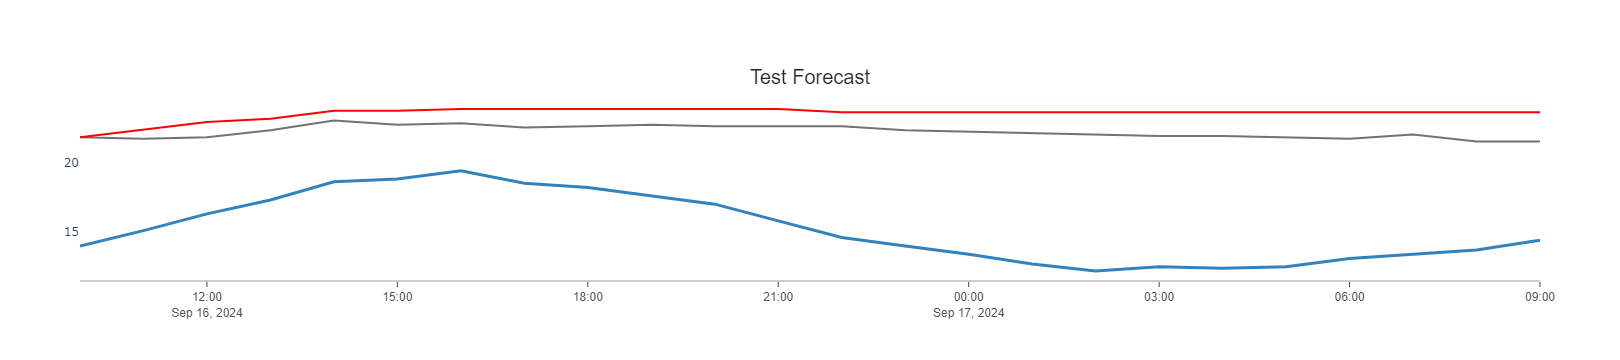

In [227]:
# Data to numpy array
x_data = test1["ts"].values
y_data2 = test1['Temperature_indoor'].values
y_data = test1["Temperature_API"].values
y_data3 = test1['Indoor_predict'].values

# Define the figure with the data
fig = go.Figure()

fig.add_trace(go.Scatter(x=x_data, y=y_data, mode='lines',
    name='Forecast Temperature',
    line=dict(color= 'rgb(49,130,189)', width=3),
    connectgaps=True))

fig.add_trace(go.Scatter(x=x_data, y=y_data2, mode='lines',
        name='Indoor Temperature (real)',
        line=dict(color= 'rgb(115,115,115)', width=2),
        connectgaps=True))

fig.add_trace(go.Scatter(x=x_data, y=y_data3, mode='lines',
        name='Prediction',
        line=dict(color= 'rgb(255, 0, 0)', width=2),
        connectgaps=True))

# Define general layout
fig.update_layout(
    xaxis=dict(showline=True, showgrid=False, showticklabels=True, linecolor='rgb(204, 204, 204)', linewidth=2, ticks='outside', tickfont=dict(family='Arial', size=12, color='rgb(82, 82, 82)')),
    yaxis=dict(showgrid=False, zeroline=False, showline=False, showticklabels=True),
    autosize=True,
    showlegend=False,
    plot_bgcolor='white')

# Add and define title and other annotations
annotations = []
# Title
annotations.append(dict(xref='paper', yref='paper', x=0.5, y=1.05,xanchor='center', yanchor='bottom', text='Test Forecast', font=dict(family='Arial',size=20, color='rgb(37,37,37)'), showarrow=False))
# Source
fig.update_layout(annotations=annotations)

In [231]:
mean_difference = (test1['Temperature_indoor'] - test1['Indoor_predict']).mean()
print('The mean difference between prediction and test values is', mean_difference)

The mean difference between prediction and test values is -1.2948035814539078


## FILTER 1: indoor-outdoor difference

#### CALCULATE PREDICTION VALUE WITH FILTER FOR indoor-outdoor difference

In [330]:
test2_predict = test.reset_index()
test2_predict['factor_indoor_predict'] = np.nan

# GET THE PREDICTED INDOOR FACTOR FOR EACH ROW IN THE TEST DATASET
for ind in test2_predict.index:
    # GET A SLICE OF THE TRAIN DB WITH SIMILAR OUTDOOR FACTORS
    slice = train[(train.factor_outdoor == (test1_predict.loc[:, ('factor_outdoor')].iloc[ind]))] # get a db slice with outdoor factors that match this row

    # FILTER 1 ===> WINDOW STATE
    tempdiff = test2_predict.loc[:, ('Temperature_Comparison_Int')].iloc[ind] # what is the temperature difference for the predicted set?
    slice = slice[(slice["Temperature_Comparison_Int"] == tempdiff)] # filter the slice based on the window state
    
    # GET A RANDOM INDOOR FACTOR FROM THIS SLICE AND APPEND IT TO THE TEST DB
    if slice.size > 0:
        # predictfactor = (slice.loc[:, ('factor_indoor')].sample(n=1, replace=False)).astype(float).values[0] # get one random value for indoor factor from this slice
        predictfactor = slice.loc[:, ('factor_indoor')].median() # get MEAN/MEDIAN value for indoor factor from this slice 
    else:
        predictfactor = 0
    
    # print(predictfactor, ind)
    test2_predict.loc[:, ('factor_indoor_predict')].iloc[ind] = predictfactor

test2_predict = test2_predict[test2_predict['factor_indoor_predict'].notna()] ## keep only the rows with prediction values
test2 = test2_predict.reset_index()  ## reset the index again to bridge nan prediction factors

## USE THIS FACTOR TO CALCULATE PREDICTED INDOOR TEMPERATURES
# Take the current temperature to start (fist value of the testset)
test2.loc[:, ('Indoor_predict')] = test2['Temperature_indoor'].iloc[0]

# calculate the predicted indoor temperature for each row by accessing the previous row
for i in range(1, len(test2)):
    test2.loc[i, 'Indoor_predict'] = test2.loc[i, 'factor_indoor_predict'] * test2.loc[i-1, 'Indoor_predict'] + test2.loc[i-1, 'Indoor_predict']

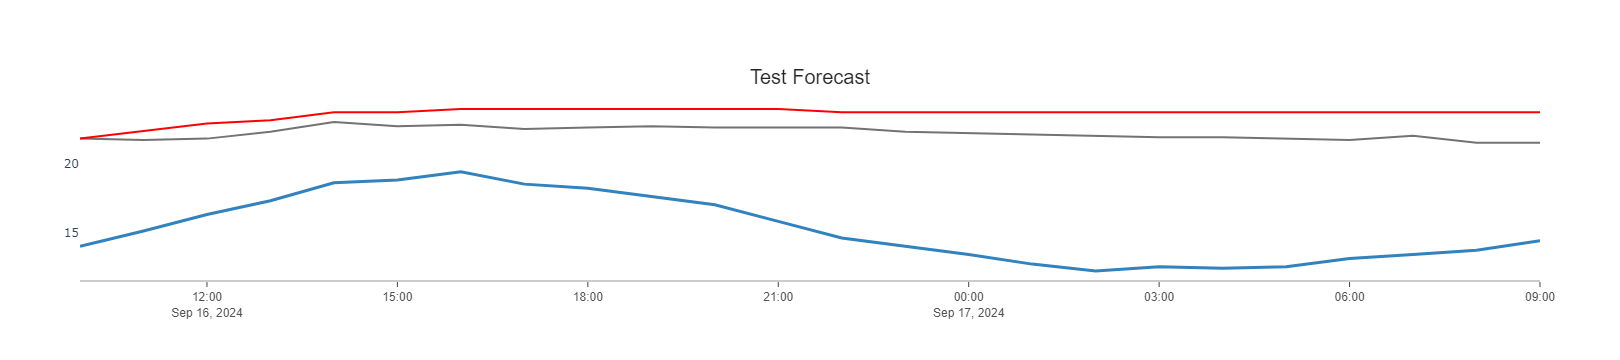

In [332]:
## VISUALIZE THE PREDICTIONS
# Data to numpy array
x_data = test2["ts"].values
y_data2 = test2['Temperature_indoor'].values
y_data = test2["Temperature_API"].values
y_data3 = test2['Indoor_predict'].values

# Define the figure with the data
fig = go.Figure()

fig.add_trace(go.Scatter(x=x_data, y=y_data, mode='lines',
    name='Forecast Temperature',
    line=dict(color= 'rgb(49,130,189)', width=3),
    connectgaps=True))

fig.add_trace(go.Scatter(x=x_data, y=y_data2, mode='lines',
        name='Indoor Temperature (real)',
        line=dict(color= 'rgb(115,115,115)', width=2),
        connectgaps=True))

fig.add_trace(go.Scatter(x=x_data, y=y_data3, mode='lines',
        name='Indoor Temperature (prediction)',
        line=dict(color= 'rgb(255, 0, 0)', width=2),
        connectgaps=True))

# Define general layout
fig.update_layout(
    xaxis=dict(showline=True, showgrid=False, showticklabels=True, linecolor='rgb(204, 204, 204)', linewidth=2, ticks='outside', tickfont=dict(family='Arial', size=12, color='rgb(82, 82, 82)')),
    yaxis=dict(showgrid=False, zeroline=False, showline=False, showticklabels=True),
    autosize=True,
    showlegend=False,
    plot_bgcolor='white')

# Add and define title and other annotations
annotations = []
# Title
annotations.append(dict(xref='paper', yref='paper', x=0.5, y=1.05,xanchor='center', yanchor='bottom', text='Test Forecast', font=dict(family='Arial',size=20, color='rgb(37,37,37)'), showarrow=False))
# Source
fig.update_layout(annotations=annotations)

In [334]:
mean_difference = (test2['Temperature_indoor'] - test2['Indoor_predict']).mean()
print('The mean difference between prediction and test values is', mean_difference)

The mean difference between prediction and test values is -1.3831269736890626


## FILTER 2: window state

#### CALCULATE PREDICTION VALUE WITH FILTER FOR WINDOW (OPEN/CLOSED)

In [324]:
test3_predict = test.reset_index()
test3_predict['factor_indoor_predict'] = np.nan

# GET THE PREDICTED INDOOR FACTOR FOR EACH ROW IN THE TEST DATASET
for ind in test3_predict.index:
    # GET A SLICE OF THE TRAIN DB WITH SIMILAR OUTDOOR FACTORS
    slice = train[(train.factor_outdoor == (test3_predict.loc[:, ('factor_outdoor')].iloc[ind]))] # get a db slice with outdoor factors that match this row

    # FILTER 1 ===> WINDOW STATE
    windowstate = test3_predict.loc[:, ('window_door')].iloc[ind] # what is the window state for the predicted set?
    slice = slice[(slice.window_door == windowstate)] # filter the slice based on the window state
    
    # GET A RANDOM INDOOR FACTOR FROM THIS SLICE AND APPEND IT TO THE TEST DB
    if slice.size > 0:
        # predictfactor = (slice.loc[:, ('factor_indoor')].sample(n=1, replace=False)).astype(float).values[0] # get one random value for indoor factor from this slice
        predictfactor = slice.loc[:, ('factor_indoor')].median() # get MEAN/MEDIAN value for indoor factor from this slice 
    else:
        predictfactor = 0
    
    # print(predictfactor, ind)
    test3_predict.loc[:, ('factor_indoor_predict')].iloc[ind] = predictfactor

test3_predict = test3_predict[test3_predict['factor_indoor_predict'].notna()] ## keep only the rows with prediction values
test3 = test3_predict.reset_index()  ## reset the index again to bridge nan prediction factors

## USE THIS FACTOR TO CALCULATE PREDICTED INDOOR TEMPERATURES
# Take the current temperature to start (fist value of the testset)
test3.loc[:, ('Indoor_predict')] = test3['Temperature_indoor'].iloc[0]

# calculate the predicted indoor temperature for each row by accessing the previous row
for i in range(1, len(test3)):
    test3.loc[i, 'Indoor_predict'] = test3.loc[i, 'factor_indoor_predict'] * test3.loc[i-1, 'Indoor_predict'] + test3.loc[i-1, 'Indoor_predict']

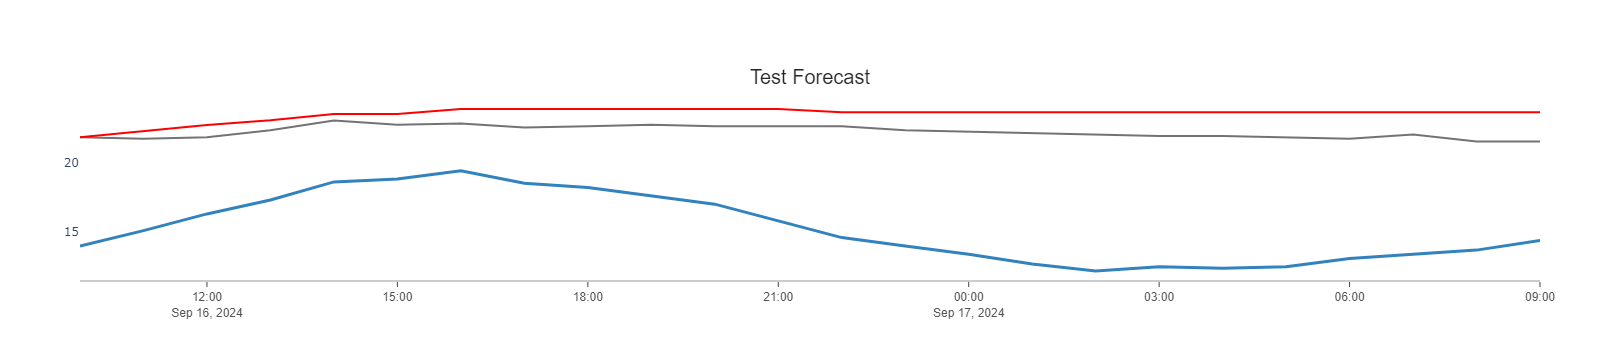

In [326]:
## VISUALIZE THE PREDICTIONS
# Data to numpy array
x_data = test3["ts"].values
y_data2 = test3['Temperature_indoor'].values
y_data = test3["Temperature_API"].values
y_data3 = test3['Indoor_predict'].values

# Define the figure with the data
fig = go.Figure()

fig.add_trace(go.Scatter(x=x_data, y=y_data, mode='lines',
    name='Forecast Temperature',
    line=dict(color= 'rgb(49,130,189)', width=3),
    connectgaps=True))

fig.add_trace(go.Scatter(x=x_data, y=y_data2, mode='lines',
        name='Indoor Temperature (real)',
        line=dict(color= 'rgb(115,115,115)', width=2),
        connectgaps=True))

fig.add_trace(go.Scatter(x=x_data, y=y_data3, mode='lines',
        name='Indoor Temperature (prediction)',
        line=dict(color= 'rgb(255, 0, 0)', width=2),
        connectgaps=True))

# Define general layout
fig.update_layout(
    xaxis=dict(showline=True, showgrid=False, showticklabels=True, linecolor='rgb(204, 204, 204)', linewidth=2, ticks='outside', tickfont=dict(family='Arial', size=12, color='rgb(82, 82, 82)')),
    yaxis=dict(showgrid=False, zeroline=False, showline=False, showticklabels=True),
    autosize=True,
    showlegend=False,
    plot_bgcolor='white')

# Add and define title and other annotations
annotations = []
# Title
annotations.append(dict(xref='paper', yref='paper', x=0.5, y=1.05,xanchor='center', yanchor='bottom', text='Test Forecast', font=dict(family='Arial',size=20, color='rgb(37,37,37)'), showarrow=False))
# Source
fig.update_layout(annotations=annotations)

In [328]:
mean_difference = (test3['Temperature_indoor'] - test3['Indoor_predict']).mean()
print('The mean difference between prediction and test values is', mean_difference)

The mean difference between prediction and test values is -1.2601906293104685


### COMBINED

In [269]:
test3_COMBINED_predict = test.reset_index()
test3_COMBINED_predict['factor_indoor_predict'] = np.nan

# GET THE PREDICTED INDOOR FACTOR FOR EACH ROW IN THE TEST DATASET
for ind in test3_COMBINED_predict.index:
    # GET A SLICE OF THE TRAIN DB WITH SIMILAR OUTDOOR FACTORS
    slice = train[(train.factor_outdoor == (test3_COMBINED_predict.loc[:, ('factor_outdoor')].iloc[ind]))] # get a db slice with outdoor factors that match this row

    # FILTER 1 ===> TEMPERATURE COMPARISON
    tempdiff = test3_COMBINED_predict.loc[:, ('Temperature_Comparison_Int')].iloc[ind] # what is the window state for the predicted set?
    slice1 = slice[(slice.Temperature_Comparison_Int == tempdiff)] # filter the slice based on the window state
    if slice1.size > 0:
        slice1_ = slice1
    else: 
        slice1_ = slice

    # FILTER 2 ===> WINDOW STATE
    windowstate = test3_COMBINED_predict.loc[:, ('window_door')].iloc[ind] # what is the light state for the predicted set?
    slice2 = slice1_[(slice1_.window_door == windowstate)] # filter the slice based on the light state
    if slice2.size > 0:
        Final_slice = slice2
    else:
        Final_slice = slice1_
    
    # GET A RANDOM INDOOR FACTOR FROM THIS SLICE AND APPEND IT TO THE TEST DB
    # predictfactor = (slice.loc[:, ('factor_indoor')].sample(n=1, replace=False)).astype(float).values[0] # get one random value for indoor factor from this slice
    predictfactor = Final_slice.loc[:, ('factor_indoor')].median() # get MEAN/MEDIAN value for indoor factor from this slice
    
    # print(predictfactor, ind)
    test3_COMBINED_predict.loc[:, ('factor_indoor_predict')].iloc[ind] = predictfactor


test3_COMBINED_predict = test3_COMBINED_predict[test3_COMBINED_predict['factor_indoor_predict'].notna()] ## keep only the rows with prediction values
test3_COMBINED = test3_COMBINED_predict.reset_index()  ## reset the index again to bridge nan prediction factors

# to start, take the current temperature to start (fist value of the testset)
test3_COMBINED.loc[:, ('Indoor_predict')] = test3_COMBINED['Temperature_indoor'].iloc[0]

# calculate the predicted indoor temperature for each row by accessing the previous row
for i in range(1, len(test3_COMBINED)):
    test3_COMBINED.loc[i, 'Indoor_predict'] = test3_COMBINED.loc[i, 'factor_indoor_predict'] * test3_COMBINED.loc[i-1, 'Indoor_predict'] + test3_COMBINED.loc[i-1, 'Indoor_predict']


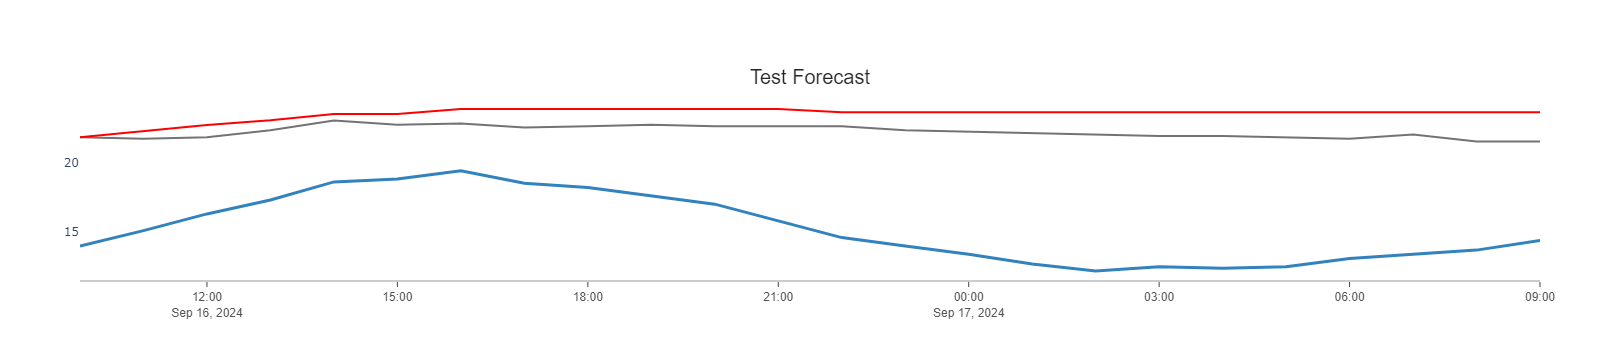

In [271]:
## VISUALIZE THE PREDICTIONS
# Data to numpy array
x_data = test3_COMBINED["ts"].values
y_data2 = test3_COMBINED['Temperature_indoor'].values
y_data = test3_COMBINED["Temperature_API"].values
y_data3 = test3_COMBINED['Indoor_predict'].values

# Define the figure with the data
fig = go.Figure()

fig.add_trace(go.Scatter(x=x_data, y=y_data, mode='lines',
    name='Forecast Temperature',
    line=dict(color= 'rgb(49,130,189)', width=3),
    connectgaps=True))

fig.add_trace(go.Scatter(x=x_data, y=y_data2, mode='lines',
        name='Indoor Temperature (real)',
        line=dict(color= 'rgb(115,115,115)', width=2),
        connectgaps=True))

fig.add_trace(go.Scatter(x=x_data, y=y_data3, mode='lines',
        name='Indoor Temperature (prediction)',
        line=dict(color= 'rgb(255, 0, 0)', width=2),
        connectgaps=True))

# Define general layout
fig.update_layout(
    xaxis=dict(showline=True, showgrid=False, showticklabels=True, linecolor='rgb(204, 204, 204)', linewidth=2, ticks='outside', tickfont=dict(family='Arial', size=12, color='rgb(82, 82, 82)')),
    yaxis=dict(showgrid=False, zeroline=False, showline=False, showticklabels=True),
    autosize=True,
    showlegend=False,
    plot_bgcolor='white')

# Add and define title and other annotations
annotations = []
# Title
annotations.append(dict(xref='paper', yref='paper', x=0.5, y=1.05,xanchor='center', yanchor='bottom', text='Test Forecast', font=dict(family='Arial',size=20, color='rgb(37,37,37)'), showarrow=False))
# Source
fig.update_layout(annotations=annotations)

In [273]:
mean_difference = (test3_COMBINED['Temperature_indoor'] - test3_COMBINED['Indoor_predict']).mean()
print('The mean difference between prediction and test values is', mean_difference)

The mean difference between prediction and test values is -1.2601906293104685


## FILTER 3: light (shade/no shade)

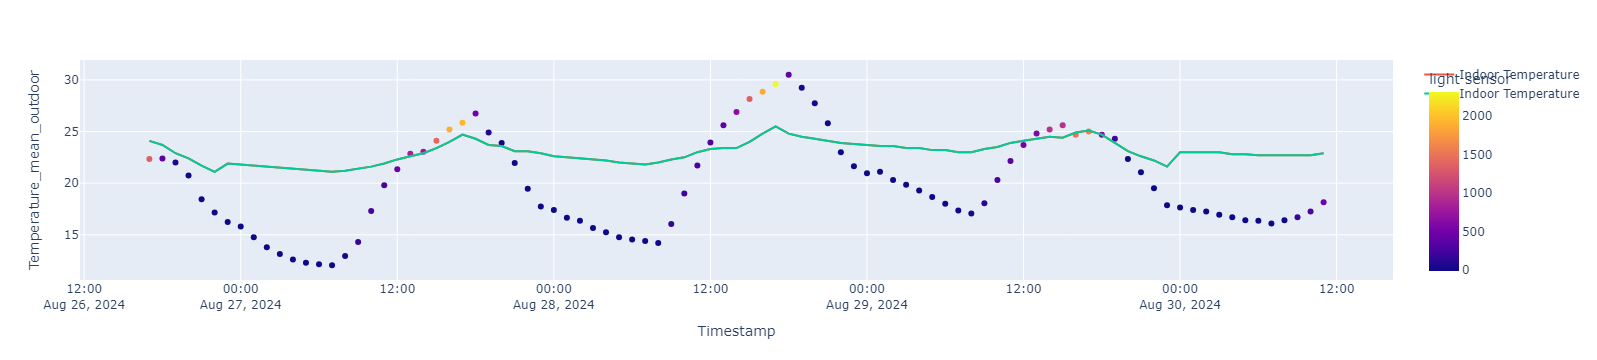

In [52]:
with warnings.catch_warnings(): ## Ignore this future warning since it is a Plotly problem, not a problem with my code
    warnings.simplefilter("ignore", FutureWarning)
    # plotly code
    fig = px.scatter(test, x="Timestamp", y="Temperature_mean_outdoor", color="light sensor", hover_data=["weather_main", "Temperature_indoor"])
    Timestamp_h = test['Timestamp'].values
    Temperature_in_h = test['Temperature_indoor'].values
    fig.add_trace(go.Scatter(x=Timestamp_h, y=Temperature_in_h,
                    mode='lines',
                    name='Indoor Temperature'))
    fig.add_trace(go.Scatter(x=Timestamp_h, y=Temperature_in_h,
                mode='lines',
                name='Indoor Temperature'))
    fig.update_traces(textposition="bottom right")
    fig.show()

It does indeed seem like the indoor temperature rises more while the light intensity is highest (along with the outdoor temperature)

#### CALCULATE PREDICTION VALUE WITH FILTER FOR LIGHT VALUE

In [292]:
test3_predict = test.reset_index()
test3_predict['factor_indoor_predict'] = np.nan

# GET THE PREDICTED INDOOR FACTOR FOR EACH ROW IN THE TEST DATASET
for ind in test3_predict.index:
    # GET A SLICE OF THE TRAIN DB WITH SIMILAR OUTDOOR FACTORS
    slice = train[(train.factor_outdoor == (test3_COMBINED_predict.loc[:, ('factor_outdoor')].iloc[ind]))] # get a db slice with outdoor factors that match this row

    # FILTER 2 ===> LIGHT INTENSITY (CAT)
    lightintensity = test3_predict.loc[:, ('shade_left')].iloc[ind] # what is the light state for the predicted set?
    slice2 = slice[(slice.shade_left == lightintensity)] # filter the slice based on the light state
    if slice2.size > 0:
        Final_slice = slice2
    else:
        Final_slice = slice
    
    # GET A RANDOM INDOOR FACTOR FROM THIS SLICE AND APPEND IT TO THE TEST DB
    # predictfactor = (slice.loc[:, ('factor_indoor')].sample(n=1, replace=False)).astype(float).values[0] # get one random value for indoor factor from this slice
    predictfactor = Final_slice.loc[:, ('factor_indoor')].median() # get MEAN/MEDIAN value for indoor factor from this slice
    
    # print(predictfactor, ind)
    test3_predict.loc[:, ('factor_indoor_predict')].iloc[ind] = predictfactor

test3_predict = test3_predict[test3_predict['factor_indoor_predict'].notna()] ## keep only the rows with prediction values
test3 = test3_predict.reset_index()  ## reset the index again to bridge nan prediction factors

# to start, take the current temperature to start (fist value of the testset)
test3.loc[:, ('Indoor_predict')] = test3['Temperature_indoor'].iloc[0]

# calculate the predicted indoor temperature for each row by accessing the previous row
for i in range(1, len(test3)):
    test3.loc[i, 'Indoor_predict'] = test3.loc[i, 'factor_indoor_predict'] * test3.loc[i-1, 'Indoor_predict'] + test3.loc[i-1, 'Indoor_predict']

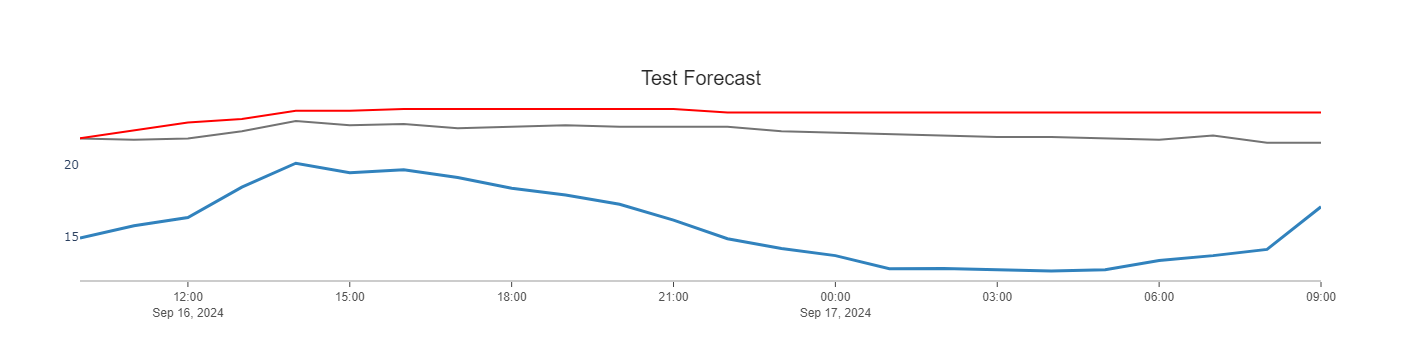

In [296]:
# Data to numpy array
x_data = test3["ts"].values
y_data2 = test3['Temperature_indoor'].values
y_data = test3["Temperature_mean_outdoor"].values
y_data3 = test3['Indoor_predict'].values

# Define the figure with the data
fig = go.Figure()

fig.add_trace(go.Scatter(x=x_data, y=y_data, mode='lines',
    name='Forecast Temperature',
    line=dict(color= 'rgb(49,130,189)', width=3),
    connectgaps=True))

fig.add_trace(go.Scatter(x=x_data, y=y_data2, mode='lines',
        name='Indoor Temperature (real)',
        line=dict(color= 'rgb(115,115,115)', width=2),
        connectgaps=True))

fig.add_trace(go.Scatter(x=x_data, y=y_data3, mode='lines',
        name='Prediction',
        line=dict(color= 'rgb(255, 0, 0)', width=2),
        connectgaps=True))

# Define general layout
fig.update_layout(
    xaxis=dict(showline=True, showgrid=False, showticklabels=True, linecolor='rgb(204, 204, 204)', linewidth=2, ticks='outside', tickfont=dict(family='Arial', size=12, color='rgb(82, 82, 82)')),
    yaxis=dict(showgrid=False, zeroline=False, showline=False, showticklabels=True),
    autosize=True,
    showlegend=False,
    plot_bgcolor='white')

# Add and define title and other annotations
annotations = []
# Title
annotations.append(dict(xref='paper', yref='paper', x=0.5, y=1.05,xanchor='center', yanchor='bottom', text='Test Forecast', font=dict(family='Arial',size=20, color='rgb(37,37,37)'), showarrow=False))
# Source
fig.update_layout(annotations=annotations)

In [318]:
test4_COMBINED_predict = test.reset_index()
test4_COMBINED_predict['factor_indoor_predict'] = np.nan

# GET THE PREDICTED INDOOR FACTOR FOR EACH ROW IN THE TEST DATASET
for ind in test4_COMBINED_predict.index:
    # GET A SLICE OF THE TRAIN DB WITH SIMILAR OUTDOOR FACTORS
    slice = train[(train.factor_outdoor == (test4_COMBINED_predict.loc[:, ('factor_outdoor')].iloc[ind]))] # get a db slice with outdoor factors that match this row

    # # FILTER 1 ===> TEMPERATURE COMPARISON
    # tempdiff = test4_COMBINED_predict.loc[:, ('Temperature_Comparison_Int')].iloc[ind] # what is the window state for the predicted set?
    # slice1 = slice[(slice.Temperature_Comparison_Int == tempdiff)] # filter the slice based on the window state
    # if slice1.size > 0:
    #     slice1_ = slice1
    # else: 
    #     slice1_ = slice

    # FILTER 2 ===> WINDOW STATE
    windowstate = test4_COMBINED_predict.loc[:, ('window_door')].iloc[ind] # what is the light state for the predicted set?
    slice2 = slice[(slice.window_door == windowstate)] # filter the slice based on the light state
    if slice2.size > 0:
        slice2_ = slice2
    else:
        slice2_ = slice

    # FILTER 2 ===> curtain
    shade = test4_COMBINED_predict.loc[:, ('shade_left')].iloc[ind] # what is the window state for the predicted set?
    slice3 = slice2_[(slice2_.shade_left == shade)] # filter the slice based on the window state
    if slice3.size > 0:
        Final_slice = slice3
    else:
        Final_slice = slice2_
    
    # GET A RANDOM INDOOR FACTOR FROM THIS SLICE AND APPEND IT TO THE TEST DB
    # predictfactor = (slice.loc[:, ('factor_indoor')].sample(n=1, replace=False)).astype(float).values[0] # get one random value for indoor factor from this slice
    predictfactor = Final_slice.loc[:, ('factor_indoor')].median() # get MEAN/MEDIAN value for indoor factor from this slice
    # print(predictfactor, ind)
    test4_COMBINED_predict.loc[:, ('factor_indoor_predict')].iloc[ind] = predictfactor

test4_COMBINED_predict = test4_COMBINED_predict[test4_COMBINED_predict['factor_indoor_predict'].notna()] ## keep only the rows with prediction values
test4_COMBINED = test4_COMBINED_predict.reset_index()  ## reset the index again to bridge nan prediction factors

# to start, take the current temperature to start (fist value of the testset)
test4_COMBINED.loc[:, ('Indoor_predict')] = test4_COMBINED['Temperature_indoor'].iloc[0]

# calculate the predicted indoor temperature for each row by accessing the previous row
for i in range(1, len(test4_COMBINED)):
    test4_COMBINED.loc[i, 'Indoor_predict'] = test4_COMBINED.loc[i, 'factor_indoor_predict'] * test4_COMBINED.loc[i-1, 'Indoor_predict'] + test4_COMBINED.loc[i-1, 'Indoor_predict']

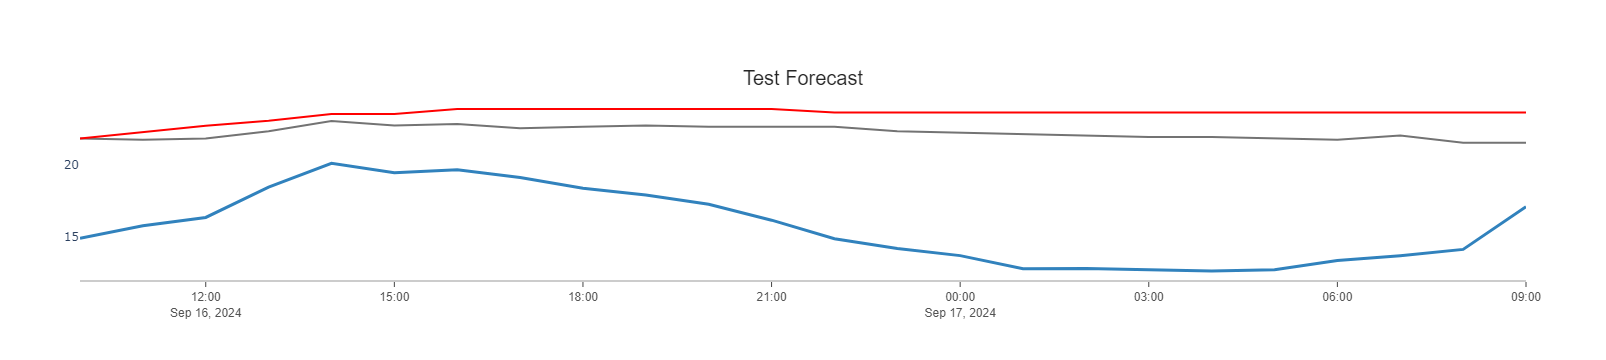

In [320]:
# Data to numpy array
x_data = test4_COMBINED["ts"].values
y_data2 = test4_COMBINED['Temperature_indoor'].values
y_data = test4_COMBINED["Temperature_mean_outdoor"].values
y_data3 = test4_COMBINED['Indoor_predict'].values

# Define the figure with the data
fig = go.Figure()

fig.add_trace(go.Scatter(x=x_data, y=y_data, mode='lines',
    name='Forecast Temperature',
    line=dict(color= 'rgb(49,130,189)', width=3),
    connectgaps=True))

fig.add_trace(go.Scatter(x=x_data, y=y_data2, mode='lines',
        name='Indoor Temperature (real)',
        line=dict(color= 'rgb(115,115,115)', width=2),
        connectgaps=True))

fig.add_trace(go.Scatter(x=x_data, y=y_data3, mode='lines',
        name='Prediction',
        line=dict(color= 'rgb(255, 0, 0)', width=2),
        connectgaps=True))

# Define general layout
fig.update_layout(
    xaxis=dict(showline=True, showgrid=False, showticklabels=True, linecolor='rgb(204, 204, 204)', linewidth=2, ticks='outside', tickfont=dict(family='Arial', size=12, color='rgb(82, 82, 82)')),
    yaxis=dict(showgrid=False, zeroline=False, showline=False, showticklabels=True),
    autosize=True,
    showlegend=False,
    plot_bgcolor='white')

# Add and define title and other annotations
annotations = []
# Title
annotations.append(dict(xref='paper', yref='paper', x=0.5, y=1.05,xanchor='center', yanchor='bottom', text='Test Forecast', font=dict(family='Arial',size=20, color='rgb(37,37,37)'), showarrow=False))
# Source
fig.update_layout(annotations=annotations)

In [322]:
mean_difference = (test4_COMBINED['Temperature_indoor'] - test4_COMBINED['Indoor_predict']).mean()
print('The mean difference between prediction and test values is', mean_difference)

The mean difference between prediction and test values is -1.2601906293104685
